# Анализ корпуса на основе текстов из первого задания письменной части IELTS 

*** *При выполнении проектной деятельности я пользовалась материалами курса, консультировалась с преподавателями и с ChatGPT :)*

** Данные хранятся в Pandas DataFrame, так как это позволяет удобно хранить тексты вместе с метаданными (тип задания, doc_id), добавлять новые вычисленные признаки (токены, POS-счётчики, частоты), быстро фильтровать тексты по типам заданий и формировать итоговые таблицы без ручной обработки файлов

In [167]:
pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [168]:
from pathlib import Path
import re
import json                     # для бота в будущем

from collections import Counter
import pandas as pd             # для таблиц, DataFrame
import numpy as np              # математические действия, округления
import matplotlib.pyplot as plt # для графиков
import random                   # для проверок случайного текста из корпуса


from nltk.stem import WordNetLemmatizer # лемматизация (NLTK)
lemmatizer = WordNetLemmatizer()

!pip install wordcloud
from wordcloud import WordCloud


!pip install nltk
import nltk
from nltk.corpus import stopwords # скачиваем список английских стоп-слов


nltk.download("stopwords")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng") # в некоторых версиях NLTK нужна именно *_eng

# IELTS более принят для британского английского, в то время, как, например,
# TOEFL - для американского. Однако, это не исключает, что текст IELTS
# может быть написан на американском варианте. Рассмотрим это с помощью...

!pip install git+https://github.com/cdpierse/breame


import breame                         # основная библиотека
import breame.spelling as brsp        # модуль со словарём орфографии (американский "color" и британский "colour")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/cdpierse/breame to c:\users\user\appdata\local\temp\pip-req-build-et2cfenn
  Resolved https://github.com/cdpierse/breame to commit 1bd0758ff625b155e5bc3687e6c614a8755b0e6d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/cdpierse/breame 'C:\Users\user\AppData\Local\Temp\pip-req-build-et2cfenn'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [169]:
# Путь к исходному файлу корпуса (текстовый файл с разметкой вида: ### <id> ... --- <text>)
IN_TXT = Path("corpus_manual.txt")  # если файл лежит рядом с ноутбуком
# IN_TXT = Path("/content/drive/MyDrive/project_Krylova/corpus_manual.txt")  # пример для Google Drive

# Папка, куда сохраняем результаты
OUT_DIR = Path("out_project_Krylova")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Порог по заданию IELTS Writing Task 1
MIN_WORDS = 150

In [172]:
# Парсинг корпуса из corpus_manual.txt → DataFrame df


# Формат записи ожидается такой:

# ### 0001 - номер текста
# source_url: ... - ссылка на источник, откуда взят текст
# chart_type: ... - тип графика
# band: ... - к-во баллов (если есть)
# ---    (разделитель между информацией о тексте и самим текстом)
# <text> (сам текст)

raw_text = IN_TXT.read_text(encoding="utf-8")

# Разбиваем на записи: каждая начинается с "### <id>"
parts = re.split(r"(?m)^###\s*", raw_text)
parts = [p.strip() for p in parts if p.strip()] # убираем лишние пробелы

records = [] # список, куда будем складывать данные

for part in parts:
    lines = part.splitlines()  # разбиваем запись на строки

    # Первая строка — doc_id (добавляем нули слева, так как текстов всего планируется из трёхзначного числа)
    doc_id = lines[0].strip().zfill(4)

    # Создание переменных, которые впоследствии будут в таблицах
    source_url = None
    chart_type = None
    band = None
    text_lines = []


    # Теперь берём все строки, кроме первой - распределяем их по переменным
    for line in lines[1:]:
        line_stripped = line.strip()

        if line_stripped.lower().startswith("source_url:"):
            source_url = line_stripped.split(":", 1)[1].strip()

        elif line_stripped.lower().startswith("chart_type:"):
            chart_type = line_stripped.split(":", 1)[1].strip()

        elif line_stripped.lower().startswith("band:"):
            band = line_stripped.split(":", 1)[1].strip()

        elif line_stripped.startswith("----"):
            continue

        else:
            text_lines.append(line)


    # Склеиваем строки текста обратно в одну строку
    text_raw = "\n".join(text_lines).strip()
    # Формируем словарь и кладём в список
    records.append({
        "doc_id": doc_id,
        "source_url": source_url,
        "chart_type": chart_type,
        "band": band,
        "text_raw": text_raw
    })

df = pd.DataFrame(records)
df["text_raw"] = (
    df["text_raw"]
    .str.replace(r"^-+\s*", "", regex=True)  # убираем --- в начале
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# В столбце band приводим показатель к числу;
# Если значение нельзя перевести в число — будет выдано NaN
df["band"] = pd.to_numeric(df["band"], errors="coerce")

# Проверка, что всё сработало и все тексты были прочтены
print(f"Записей в корпусе: {len(df)}")
display(df.head())


Записей в корпусе: 121


,doc_id,source_url,chart_type,band,text_raw
0,0001,https://ieltsliz.com/ielts-diagram/,process_diagram,NaN,The diagram illustrates how an Australian town...
1,0002,https://ieltsliz.com/ielts-pie-chart-task-1-mo...,pie_chart,9.0,The two pie charts illustrate the proportion o...
2,0003,https://ieltsliz.com/dec-2016-ielts-writing-ta...,mixed,8.0,The bar chart and pie charts illustrate the pe...
3,0004,https://ieltsliz.com/ielts-diagram-model-answe...,mixed,9.0,The diagrams illustrate the steps and equipmen...
4,0005,https://ieltsliz.com/ielts-table-band-9-model-...,table,9.0,The table gives information about how many ful...


In [ ]:
# Базовая статистика по типам графиков (для отчёта)
# - перевод с технических английских названий на русский

type_name = {
    "process_diagram": "Описание процесса",
    "pie_chart": "Круговая диаграмма",
    "bar_chart": "Столбчатая диаграмма",
    "line_graph": "Линейный график",
    "table": "Таблица",
    "map": "Карта",
    "mixed": "Смешанный тип",
}

# Добавляем русское название типа задания в основной корпус
df_ok["chart_type_rus"] = df_ok["chart_type"].map(type_name).fillna("Unknown type")


summary_types = (
    df.assign(chart_type_rus=df["chart_type"].map(type_name).fillna("Неизвестный тип"))
      .groupby(["chart_type", "chart_type_rus"])
      .size() # счёт к-ва таких текстов
      .reset_index(name="count")
      .sort_values("count", ascending=False) # сортируем по убыванию
)

# Проверка
print("Количество текстов в корпусе:", len(df))
summary_types


Количество текстов в корпусе: 121


,chart_type,chart_type_rus,count
0,bar_chart,Столбчатая диаграмма,32
3,mixed,Смешанный тип,18
1,line_graph,Линейный график,17
5,process_diagram,Описание процесса,17
4,pie_chart,Круговая диаграмма,16
6,table,Таблица,12
2,map,Карта,9


In [174]:
# Подсчёт слов и чистка каждого текста

def wc_simple(text: str) -> int:
    # Считаем токены, приближенно к «человеческому» и Wordовскому подсчёту:
    # - слова из букв (можно с дефисом/апострофом, т.к. есть слова типа "twenty-five", "London's")
    # - числа, проценты, форматы с запятыми (10,000)
    if text is None:
        return 0        # Если текста нет или он не был считан - возвращаем "0" слов
    text = str(text)

    tokens = re.findall(
        r"[A-Za-z]+(?:['-][A-Za-z]+)*"      # слова
        r"|\d+(?:[.,]\d+)?%?"             # числа и проценты
        r"|\d{1,3}(?:,\d{3})+",            # числа типа "10,000", если они вдруг написаны запятой
        text
    )
    return len(tokens)

def clean_text(text: str) -> str:
    # Приводим к нижнему регистру
    text = str(text).lower()

    # Оставляем только буквы, пробелы, апостроф и дефис
    text = re.sub(r"[^a-z\s'-]", " ", text)

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [176]:
# Сделаем проверку случайного текста, чтоб увидеть версии "до" и "после" чистки

df["text_clean"] = df["text_raw"].apply(clean_text)

# выбираем случайный текст - но учитываем индексацию в pandas с нуля, поэтому отнимем 1
idx = random.randint(0, len(df) - 1)

print("ID текста:", df.loc[idx, "doc_id"])
print("\n--- ДО чистки ---\n")
print(df.loc[idx, "text_raw"][:300])  # первые 300 символов

print("\n--- ПОСЛЕ чистки ---\n")
print(df.loc[idx, "text_clean"][:300])

ID текста: 0029

--- ДО чистки ---

The diagram explains the way in which bricks are made for the building industry. Overall, there are seven stages in the process, beginning with the digging up of clay and culminating in delivery. To begin, the clay used to make the bricks is dug up from the ground by a large digger. This clay is the

--- ПОСЛЕ чистки ---

the diagram explains the way in which bricks are made for the building industry overall there are seven stages in the process beginning with the digging up of clay and culminating in delivery to begin the clay used to make the bricks is dug up from the ground by a large digger this clay is then plac


In [177]:
# Минимальный порог слов для IELTS Writing Task 1 - 150 слов
# Конечно, могут зачесть текст и с некоторой погрешностью
# Однако, в критериях оценивания сказано, что за это снижают балл.
# Поэтому мы проверим корпус по этому правилу
# И сделаем анализ по текстам 150+ слов, так как наша цель -
# помочь подготовиться к как можно лучшему результату :)

# Считаем длину текста и запишем в столбец "wc_custom" для каждого
df["wc_custom"] = df["text_raw"].apply(wc_simple)

# Смотрим статистику по порогу слов
# Вывод будет к-вом текстов, которые проходят 150 слов
total = len(df)
ok_count = int((df["wc_custom"] >= MIN_WORDS).sum())
bad_count = total - ok_count

print("Всего текстов:", total)
print(f"Тексты, в которых >= {MIN_WORDS} слов:", ok_count)
print(f"Тексты, где слов не хватает (< {MIN_WORDS}):", bad_count)

# Оставляем только тексты, которые проходят порог
# + убираем старые индексы, если бы они не подошли требованиям 150 слов
# df_ok - очищенный корпус
df_ok = df[df["wc_custom"] >= MIN_WORDS].reset_index(drop=True)

# Создаём новую колонку с очищенным текстом для токенизации и частотного анализа
df_ok["text_clean"] = df_ok["text_raw"].apply(clean_text)


# Проверка текстов на порог 150 слов
# Отбираем тексты, где слов меньше MIN_WORDS
df_short = df[df["wc_custom"] < MIN_WORDS]

# Смотрим сколько таких текстов и их ID
print("\nКоличество текстов ниже порога:", len(df_short))
print("ID текстов, которые не прошли проверку:")
print(df_short["doc_id"].tolist())


Всего текстов: 121
Тексты, в которых >= 150 слов: 120
Тексты, где слов не хватает (< 150): 1

Количество текстов ниже порога: 1
ID текстов, которые не прошли проверку:
['0116']


In [178]:
# Токенизация + стоп-слова

stop_words = set(stopwords.words("english"))  # список стоп-слов

# Превращаем текст в список слов (токенов)
#    - Апостроф и дефис остаются, чтобы слова типа "London's" и "twenty-five" сохранялись
#    - Берём текст из столбца 'text_clean', где уже убраны лишние символы
df_ok["tokens"] = df_ok["text_clean"].str.findall(r"[a-z]+(?:['-][a-z]+)*")

# Создаём новый список для токенов без стоп-слов
tokens_no_stop_list = []

for words in df_ok["tokens"]:
    filtered = [w for w in words if w not in stop_words]  # фильтруем стоп-слова
    tokens_no_stop_list.append(filtered)

# Сохраняем результат в новый столбец
df_ok["tokens_no_stop"] = tokens_no_stop_list

In [179]:
# Проверка по токенизации

# Выбираем случайный текст из df_ok
sample = df_ok.sample(1).iloc[0]

print(f"ID текста: {sample['doc_id']}")

# 1) Показываем первые 200 символов оригинального текста
print("\nОРИГИНАЛ\n")
print(sample["text_clean"][:200])

# 2) Показываем первые 20 токенов до удаления стоп-слов
print("\n\nТОКЕНЫ (до стоп-слов)\n")
print(sample["tokens"][:20])

# 3) Показываем первые 20 токенов после удаления стоп-слов
print("\n\nТОКЕНЫ (после стоп-слов)\n")
print(sample["tokens_no_stop"][:20])

# 4) Проверяем количество слов до и после
print("\n\nСчёт слов")
print("До фильтрации:", len(sample["tokens"]))
print("После фильтрации:", len(sample["tokens_no_stop"]))

ID текста: 0018

ОРИГИНАЛ

the table shows the value of fish in billions of dollars that was imported to the us in and while the three pie charts illustrate the proportion of fish that the us brought in from china canada and ot


ТОКЕНЫ (до стоп-слов)

['the', 'table', 'shows', 'the', 'value', 'of', 'fish', 'in', 'billions', 'of', 'dollars', 'that', 'was', 'imported', 'to', 'the', 'us', 'in', 'and', 'while']


ТОКЕНЫ (после стоп-слов)

['table', 'shows', 'value', 'fish', 'billions', 'dollars', 'imported', 'us', 'three', 'pie', 'charts', 'illustrate', 'proportion', 'fish', 'us', 'brought', 'china', 'canada', 'countries', 'three']


Счёт слов
До фильтрации: 172
После фильтрации: 84


In [180]:
# Частотный анализ

# Топ-20 по raw (после базовой clean_text, но ДО удаления стоп-слов)

#explode() - один список на весь корпус, каждое слово в отдельной строке
#dropna() - убираем пустые элементы (если есть NaN)
#tolist() - Python-список для передачи в Counter

all_tokens_raw = df_ok["tokens"].explode().dropna().tolist()
top20_raw = Counter(all_tokens_raw).most_common(20)
df_top20_raw = pd.DataFrame(top20_raw, columns=["word", "count"])
df_top20_raw



,word,count
0,the,1828
1,in,924
2,and,759
3,of,724
4,to,572
5,a,413
6,for,268
7,was,254
8,at,196
9,from,194


In [181]:
# Топ-20 БЕЗ стоп-слов
all_tokens_ns = df_ok["tokens_no_stop"].explode().dropna().tolist()
top20_ns = Counter(all_tokens_ns).most_common(20)
df_top20_ns = pd.DataFrame(top20_ns, columns=["word", "count"])

display(df_top20_ns)


,word,count
0,years,90
1,overall,87
2,period,87
3,people,84
4,year,84
5,around,82
6,number,75
7,highest,63
8,million,62
9,uk,60


In [182]:
# Top-10: абсолютная и относительная частотность (на токенах без стоп-слов)

# Считаем общее количество токенов без стоп-слов в корпус
total_ns = len(all_tokens_ns)

# Счёт - сколько раз каждое слово встречается + 10 самых частотных из них
top10_ns = Counter(all_tokens_ns).most_common(10)

# Превращаем этот список в DataFrame для наглядности
# Колонки "word" — само слово, "count" — сколько раз встретилось
df_top10 = pd.DataFrame(top10_ns, columns=["word", "count"])

# Вычисляем относительную частотность слова
# А абсолютная будет показана в колонке "count"
df_top10["rel_%"] = (df_top10["count"] / total_ns * 100).round(3) if total_ns else 0
df_top10


,word,count,rel_%
0,years,90,0.777
1,overall,87,0.751
2,period,87,0.751
3,people,84,0.725
4,year,84,0.725
5,around,82,0.708
6,number,75,0.647
7,highest,63,0.544
8,million,62,0.535
9,uk,60,0.518


In [183]:
# Дополним статистику по текстам в Pandas

# Количество токенов без стоп-слов
def count_tokens(tokens_list):
    if tokens_list:
        return len(tokens_list)
    else:
        return 0

df_ok["tokens_no_stop_count"] = df_ok["tokens_no_stop"].apply(count_tokens)


# Количество уникальных слов (types)
def count_unique(tokens_list):
    if tokens_list:
        return len(set(tokens_list))
    else:
        return 0

df_ok["types_count"] = df_ok["tokens_no_stop"].apply(count_unique)


# TTR (Type-Token Ratio) — соотношение уникальных слов к общему числу токенов
def calc_ttr(row):
    if row["tokens_no_stop_count"] > 0:
        return row["types_count"] / row["tokens_no_stop_count"]
    else:
        return 0

df_ok["ttr"] = df_ok.apply(calc_ttr, axis=1)  # функция применяется к строкам, НЕ столбцам

# Быстрая проверка
df_ok[[
    "doc_id",
    "chart_type",
    "wc_custom",
    "tokens_no_stop_count",
    "types_count",
    "ttr"
]].head()

,doc_id,chart_type,wc_custom,tokens_no_stop_count,types_count,ttr
0,0001,process_diagram,179,87,56,0.643678
1,0002,pie_chart,177,78,46,0.589744
2,0003,mixed,202,87,51,0.586207
3,0004,mixed,194,103,77,0.747573
4,0005,table,202,99,57,0.575758


In [184]:
# Рассмотрим использование "overall" - частого слова в данном задании
# Создаём новые столбцы для результатов

df_ok["overall_count"] = 0       # сколько раз слово "overall" встречается в каждом тексте
df_ok["overall_present"] = False # True, если слово есть хотя бы один раз

# Проходимся по каждому тексту
for i in range(len(df_ok)):
    tokens = df_ok.loc[i, "tokens_no_stop"]  # список токенов без стоп-слов
    if tokens:                              # проверяем, что список не пустой
        count = tokens.count("overall")     # считаем, сколько раз встречается "overall"
    else:
        count = 0
    df_ok.loc[i, "overall_count"] = count   # записываем в столбец
    df_ok.loc[i, "overall_present"] = (count > 0)  # True, если есть хотя бы один раз

# Сколько текстов содержат слово "overall"
overall_text_count = df_ok["overall_present"].sum()
print(f"Слово 'overall' встречается в {overall_text_count} текстах из {len(df_ok)}")

# Сколько раз всего встречается слово "overall" в корпусе
overall_total_count = df_ok["overall_count"].sum()
print(f"Слово 'overall' встречается всего {overall_total_count} раз в корпусе")

# Если слово встречается 2 и более раз в тексте, отобразим ID этих текстов
docs_multiple = []
for i in range(len(df_ok)):
    if df_ok.loc[i, "overall_count"] >= 2:
        docs_multiple.append(df_ok.loc[i, "doc_id"])

if docs_multiple:
    print(f"Слово 'overall' встречается 2 и более раз в текстах: {docs_multiple}")
else:
    print("Нет текстов с 2 и более вхождениями слова 'overall'")

# Быстрая проверка
df_ok[["doc_id", "overall_count", "overall_present"]].head()

Слово 'overall' встречается в 80 текстах из 120
Слово 'overall' встречается всего 87 раз в корпусе
Слово 'overall' встречается 2 и более раз в текстах: ['0019', '0026', '0030', '0046', '0051', '0092', '0108']


,doc_id,overall_count,overall_present
0,0001,1,True
1,0002,1,True
2,0003,1,True
3,0004,1,True
4,0005,1,True


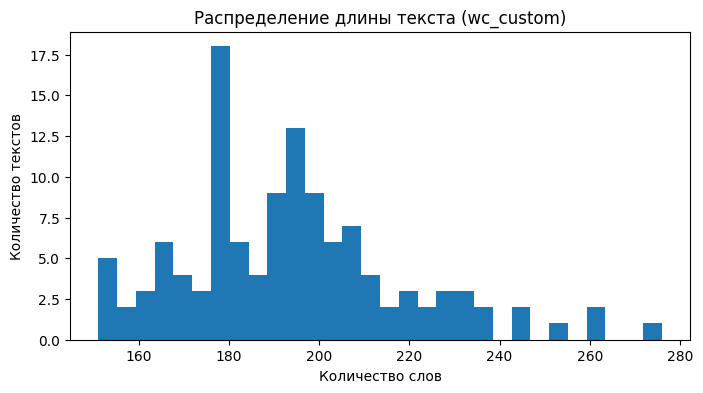

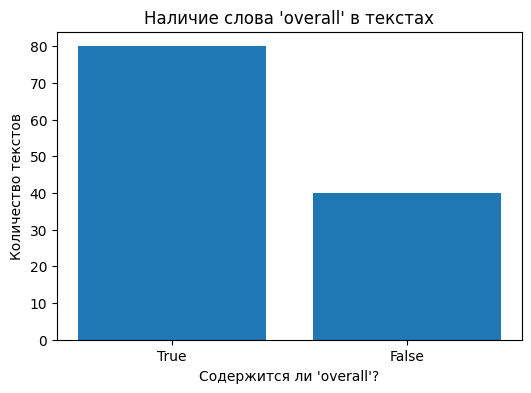

In [185]:
# Графики: распределение длины текста и доля overall

plt.figure(figsize=(8, 4))
plt.hist(df_ok["wc_custom"], bins=30)
plt.title("Распределение длины текста (wc_custom)")
plt.xlabel("Количество слов")
plt.ylabel("Количество текстов")
plt.show()

plt.figure(figsize=(6, 4))
overall_counts = df_ok["overall_present"].value_counts()
plt.bar(overall_counts.index.astype(str), overall_counts.values)
plt.title("Наличие слова 'overall' в текстах")
plt.xlabel("Содержится ли 'overall'?")
plt.ylabel("Количество текстов")
plt.show()


In [186]:
# Создаём пустой список для всех лемм без стоп-слов
lemmas_no_stop = []

# Проходим по каждому списку токенов без стоп-слов
for token_list in df_ok["tokens_no_stop"]:
    lemmas = []
    if token_list:  # проверяем, что список не пустой
        for w in token_list:
            # Лемматизация как существительное и как глагол
            a = lemmatizer.lemmatize(w, "n")
            b = lemmatizer.lemmatize(w, "v")
            # Берём короткую форму
            lemmas.append(b if len(b) <= len(a) else a)
    # Добавляем результат в общий список
    lemmas_no_stop.append(lemmas)

# Сохраняем леммы в новый столбец
df_ok["lemmas_no_stop"] = lemmas_no_stop

# Разворачиваем список лемм всех текстов в один для подсчёта частот
all_lemmas = []
for lst in lemmas_no_stop:
    if lst:
        all_lemmas.extend(lst)

# Считаем топ-30 лемм
top_lemmas = Counter(all_lemmas).most_common(30)

# Превращаем в DataFrame для наглядного отображения
df_top_lemmas = pd.DataFrame(top_lemmas, columns=["lemma", "count"])

# Выводим топ-15
df_top_lemmas.head(15)

,lemma,count
0,year,174
1,increase,92
2,spend,89
3,overall,87
4,period,87
5,people,84
6,number,84
7,around,82
8,chart,76
9,million,65


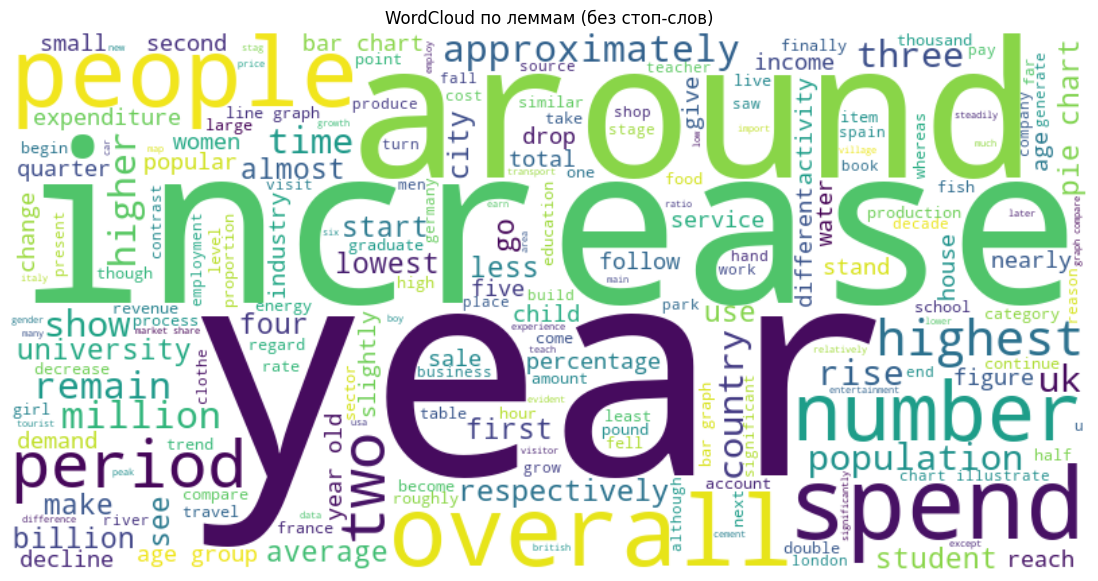

In [187]:
# Превращаем список лемм в одну строку
text_for_wc = " ".join(all_lemmas)

# Создаём объект WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

# Генерируем облако слов из текста
wc.generate(text_for_wc)

# Показываем результат
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")  # убираем оси
plt.title("WordCloud по леммам (без стоп-слов)")
plt.show()

In [188]:
# POS по типам

def pos_group(tag: str) -> str:

    if tag.startswith("NN"):
        return "NOUN"
    if tag.startswith("VB"):
        return "VERB"
    if tag.startswith("JJ"):
        return "ADJ"
    if tag.startswith("RB"):
        return "ADV"
    if tag in ("IN", "TO"):
        return "PREP"
    if tag.startswith("PRP"):
        return "PRON"
    if tag in ("DT", "PDT", "WDT"):
        return "DET"
    if tag == "CC":
        return "CONJ"

    return "OTHER"

def pos_profile(tokens):                        # статистика POS для одного текста
    tagged = nltk.pos_tag(tokens)               # ставим POS-tag каждому токену
    grouped = [pos_group(t) for _, t in tagged] # берём только tag, переводим в группу
    return Counter(grouped)                     # возвращаем частоты групп:

# POS-профиль для каждого текста в df
df_ok["pos_counter"] = df_ok["tokens_no_stop"].apply(pos_profile)

# Сводка по всему корпусу
pos_total = Counter()
for c in df_ok["pos_counter"]:
    pos_total.update(c)

# Переводим итог в таблицу + показатель результата в процентах
pos_df = pd.DataFrame(pos_total.most_common(), columns=["pos_group", "count"])
pos_df["share_%"] = (pos_df["count"] / pos_df["count"].sum() * 100).round(2)
pos_df


,pos_group,count,share_%
0,NOUN,5475,47.25
1,VERB,2320,20.02
2,ADJ,2271,19.60
3,ADV,829,7.15
4,OTHER,386,3.33
5,PREP,265,2.29
6,DET,20,0.17
7,PRON,14,0.12
8,CONJ,8,0.07


!!!!!!!!!!!!!!!!!!!!!!

In [207]:
# Пропишем функции для повторяющихся шагов ниже (POS -> top-20 -> график)
# ============================================================

def collect_words_by_group(df, tokens_col, target_group):
    # Собираем слова из df[tokens_col], которые NLTK пометил нужной группой (NOUN/VERB/ADJ/ADV)
    # tokens_col— колонка со списком токенов
    # target_group — строка "NOUN" / "VERB" / "ADJ" / "ADV"

    result = []

    for tokens in df[tokens_col]:
        tagged = nltk.pos_tag(tokens)

        for word, tag in tagged:
            # pos_group(tag) - функция из блока POS по типам
            if pos_group(tag) == target_group:
                result.append(word)

    return result


def top_n_counts(words_list, n=20):
    # Считаем частоты и возвращаем DataFrame топ
    c = Counter(words_list)
    top = c.most_common(n)

    # Делаем таблицу
    words = []
    counts = []
    for w, cnt in top:
        words.append(w)
        counts.append(cnt)

    return pd.DataFrame({"word": words, "count": counts})


def plot_top_bar(top_df, title, xlabel):
    # Строим столбчатый график для таблицы top_df (word, count)
    plt.figure(figsize=(10, 5))
    plt.bar(top_df["word"], top_df["count"])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

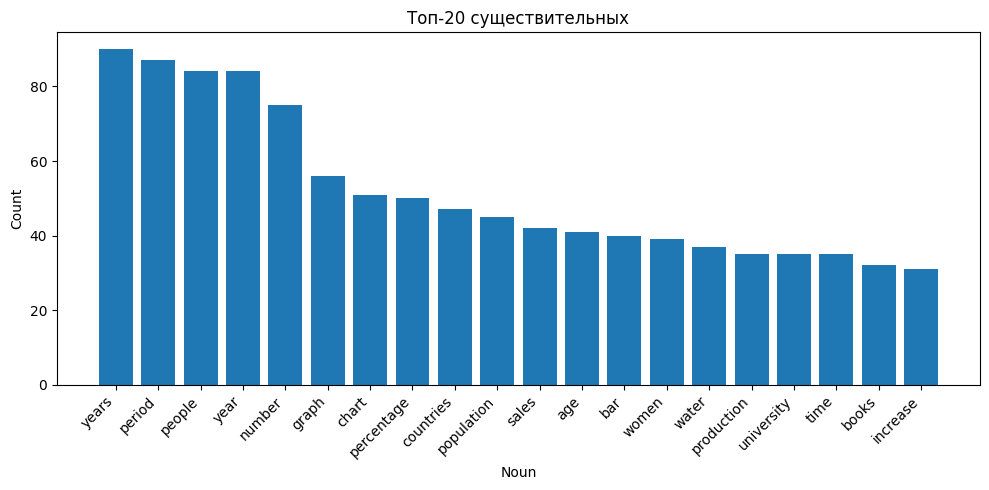

In [213]:
# Далее код будет чище - нам не нужно будет повторять одно и то же несколько раз,
# сделано это для оптимизации и чистоты кода :)

# Собираем все слова-существительные из корпуса (из tokens_no_stop)
nouns_list = collect_words_by_group(df_ok, "tokens_no_stop", "NOUN")

# Top-20
nouns_df = top_n_counts(nouns_list, n=20)
nouns_df

# График
plot_top_bar(nouns_df, "Топ-20 существительных", "Noun")

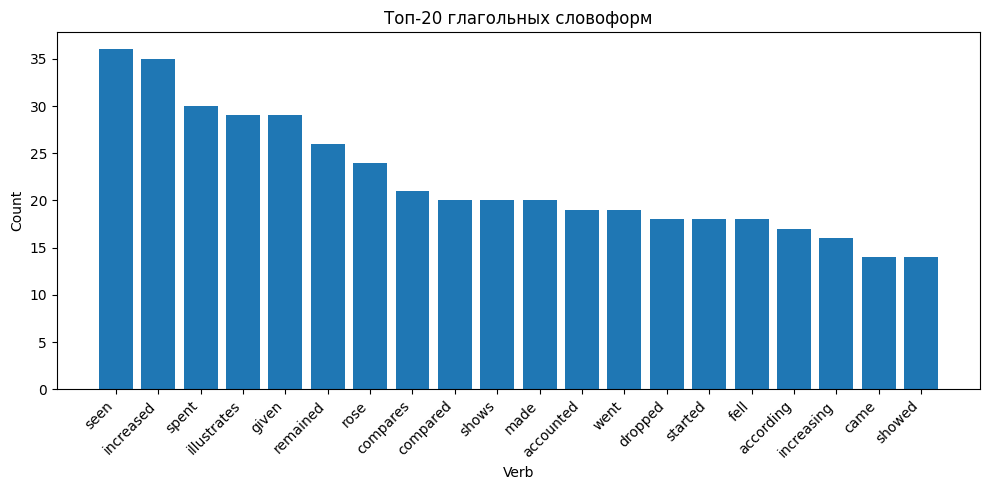

In [ ]:
# После этого по частотности идут глаголы
# Покажем наглядно Топ-20 VERB (глагольных словоформ) в виде графика

# Аналогично коду выше
# собираем все глагольные словоформы из корпуса (из tokens_no_stop)

verbs_list = collect_words_by_group(df_ok, "tokens_no_stop", "VERB")
verbs_df = top_n_counts(verbs_list, n=20)
verbs_df
plot_top_bar(verbs_df, "Топ-20 глагольных словоформ", "Verb")

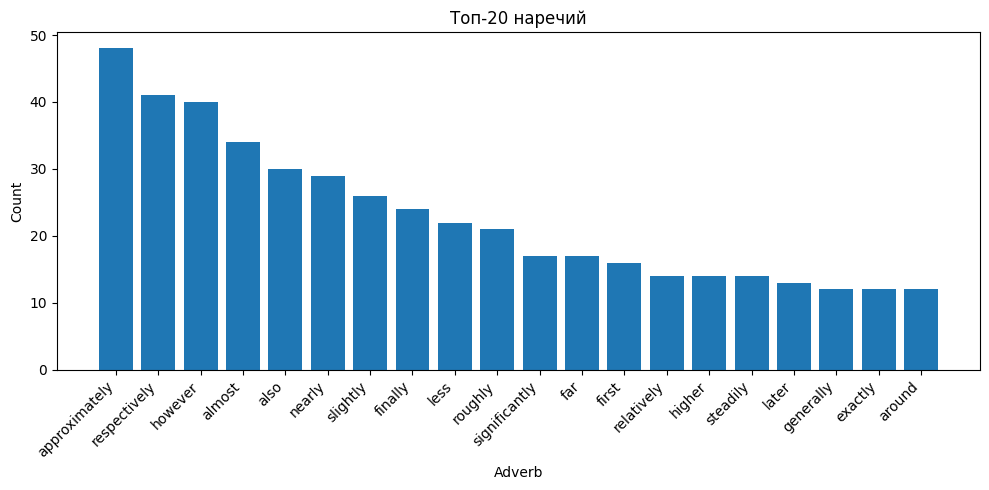

In [215]:
# В данном задании отдельное место занимают наречия -
# Они важны как связка между анализом графика, так и
# как "определитель степени" глагола (e.g. increase significantly)
# Выявим топ-20 ADV (наречия) в виде графика

# Собираем все наречия
advs_list = collect_words_by_group(df_ok, "tokens_no_stop", "ADV")
advs_df = top_n_counts(advs_list, n=20)
advs_df
plot_top_bar(advs_df, "Топ-20 наречий", "Adverb")

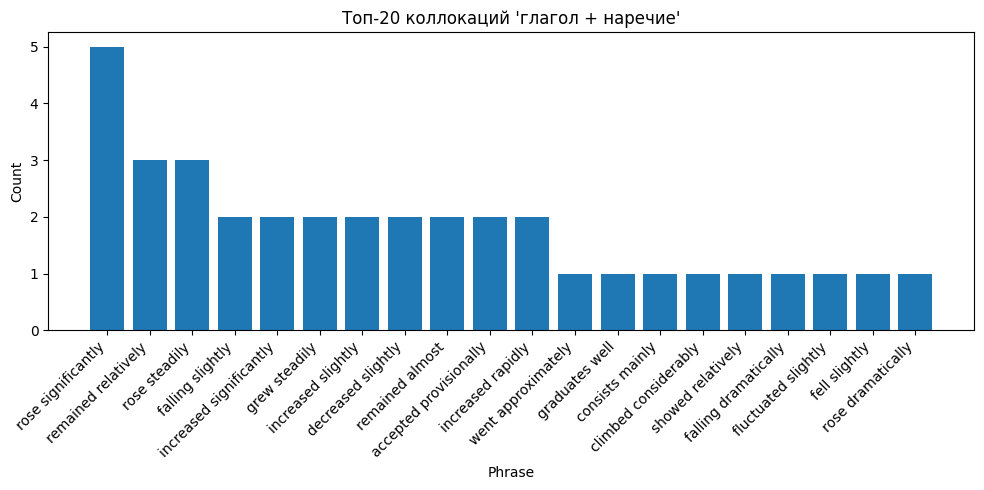

,phrase,count
0,rose significantly,5
1,remained relatively,3
2,rose steadily,3
3,falling slightly,2
4,increased significantly,2
5,grew steadily,2
6,increased slightly,2
7,decreased slightly,2
8,remained almost,2
9,accepted provisionally,2


In [216]:
# Коллокации VERB + ADV (например: "increase significantly")
# занимают отдельное место в данном задании - они как раз таки описывают графики

# Хоть и корпус получился небольшим, но в будущем его можно расширить -
# рассмотреть и тексты, написанные от руки + тексты на более низкий балл

# Изначально извлекались пары типа "bought voucher",
# что связано с вероятностной природой POS-теггера:
# в отдельных контекстах возможна неточная разметка частей речи
# Поэтому для повышения интерпретируемости результатов
# оставляем только типичные наречия для IELTS-описаний:
# слова на -ly и несколько частотных исключений

allowed_adv_no_ly = {
    "almost", "very", "too", "well", "rather",
    "relatively", "approximately"
}

def is_good_adv(word: str) -> bool:
    # Считаем наречие “подходящим”, если:
    #   1) оно заканчивается на -ly (типично для наречий)
    #   2) или оно в небольшом списке частых “IELTS-наречий” без -ly (список выше)
    if word.endswith("ly"):
        return True
    if word in allowed_adv_no_ly:
        return True
    return False


# Собираем связки VERB + ADV (соседние слова) по всему корпусу
#    Важно: мы ищем именно соседей: word[i] + word[i+1]

pairs = []  # сюда будем складывать пары

for tokens in df_ok["tokens_no_stop"]:
    tagged = nltk.pos_tag(tokens)

    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i + 1]

        # Проверяем, что это VERB + ADV по нашим группам
        if pos_group(tag1) == "VERB" and pos_group(tag2) == "ADV":

            # Дополнительно фильтруем наречие, чтобы убрать шум (voucher и т.п.)
            if is_good_adv(word2):
                pairs.append((word1, word2))


# Считаем частоты и делаем топ-20
pairs_counter = Counter(pairs)
top_pairs = pairs_counter.most_common(20)

# Делаем таблицу
phrases = []
counts = []

for pair, cnt in top_pairs:
    verb = pair[0]
    adv = pair[1]
    phrases.append(verb + " " + adv)
    counts.append(cnt)

pairs_df = pd.DataFrame({"phrase": phrases, "count": counts})

# График Top-20 связок VERB + ADV

plt.figure(figsize=(10, 5))
plt.bar(pairs_df["phrase"], pairs_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Топ-20 коллокаций 'глагол + наречие'")
plt.xlabel("Phrase")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Показываем таблицу
pairs_df

In [ ]:
# Проверяем, в каких текстах встречаются Top-20 VERB+ADV
# Берём список топ-фраз из pairs_df
top_phrases = pairs_df["phrase"].tolist()

results_rows = []  # сюда будем сохранять информацию о текстах


# Проходим по каждому тексту корпуса
for idx, row in df_ok.iterrows():

    tokens = row["tokens_no_stop"]
    tagged = nltk.pos_tag(tokens)

    text_pairs = []  # сюда собираем VERB+ADV внутри одного текста

    # перебираем соседние слова
    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i + 1]

        # проверяем условие VERB + ADV
        if pos_group(tag1) == "VERB" and pos_group(tag2) == "ADV":
            if is_good_adv(word2):
                phrase = word1 + " " + word2
                text_pairs.append(phrase)

    # проверяем, есть ли пересечение с Топ-20
    found = set(text_pairs) & set(top_phrases)

    # если хотя бы одна коллокация найдена — сохраняем текст
    if len(found) > 0:
        results_rows.append({
            "doc_id": row["doc_id"],
            "chart_type_rus": type_name.get(row["chart_type"], "Unknown type"),
            "collocations_found": list(found)
        })


# Создаём итоговую таблицу
colloc_texts_df = pd.DataFrame(results_rows)

# сортируем их для более аккуратного вида
colloc_texts_df = colloc_texts_df.sort_values(["chart_type_rus", "doc_id"])

colloc_texts_df

,doc_id,chart_type_rus,collocations_found
0,0002,Круговая диаграмма,"[went approximately, rose significantly]"
14,0046,Круговая диаграмма,[increased significantly]
5,0010,Линейный график,"[falling dramatically, fell slightly, fluctuat..."
6,0011,Линейный график,"[rose dramatically, remained relatively]"
10,0021,Линейный график,"[rose significantly, rose steadily]"
15,0050,Линейный график,[rose significantly]
16,0057,Линейный график,[falling slightly]
18,0075,Линейный график,[remained almost]
19,0076,Линейный график,[remained almost]
24,0109,Линейный график,[increased rapidly]


In [217]:
# В данной части я много консультировалась с Чатом, а также вдохновилась
# источниками, которые мне предложила Юлия Геннадьевна


mapping_raw = brsp.AMERICAN_ENGLISH_SPELLINGS

# Переводим в обычный словарь Python
mapping = dict(mapping_raw)


# Функция получает список токенов одного текста
# и проверяет, есть ли в нём слова из словаря BrE или AmE

def detect_breame_hits(tokens, mapping):

    ame_hits = []   # сюда будем складывать найденные американские формы
    bre_hits = []   # сюда — британские формы

    # Превращаем список токенов в множество (так быстрее проверять "есть ли слово")
    tokens_set = set(tokens)

    # Проходим по всем парам american -> british
    for ame_form in mapping:

        bre_form = mapping[ame_form]

        # Если в тексте встретилась американская форма
        if ame_form in tokens_set:
            ame_hits.append(ame_form)

        # Если встретилась британская форма
        if bre_form in tokens_set:
            bre_hits.append(bre_form)

    # Возвращаем найденные слова
    return ame_hits, bre_hits


# Теперь классифицируем каждый текст (даём "метку"):
# BrE  — найдено хотя бы одно британское слово из библиотеки
# AmE  — найдено хотя бы одно американское слово
# MIX  — найдены и BrE, и AmE
# none — ничего не найдено

rows = []   # сюда будем складывать результаты по каждому тексту

for index, row in df_ok.iterrows():

    tokens = row["tokens"]   # берём токены текста

    ame_hits, bre_hits = detect_breame_hits(tokens, mapping)

    # Определяем метку (label)
    if len(ame_hits) > 0 and len(bre_hits) > 0:
        label = "MIX"

    elif len(bre_hits) > 0:
        label = "BrE"

    elif len(ame_hits) > 0:
        label = "AmE"

    else:
        label = "none"

    # Сохраняем информацию о тексте
    rows.append({
        "index": index,
        "doc_id": row["doc_id"],
        "chart_type": row["chart_type"],
        "label": label,
        "ame_count": len(ame_hits),
        "bre_count": len(bre_hits),
        "ame_words": ame_hits[:10],   # первые 10 найденных AmE-слов
        "bre_words": bre_hits[:10]    # первые 10 найденных BrE-слов
    })

# Создаём итоговую таблицу
variant_df = pd.DataFrame(rows)


# Считаем, сколько текстов относится к каждой категории
summary_counts = variant_df["label"].value_counts()

# Превращаем в DataFrame
summary_df = pd.DataFrame({
    "label": summary_counts.index,
    "count": summary_counts.values
})

# Считаем показатель в процентах, результат будет отображён в сотых
total = summary_df["count"].sum()

percentages = []

for c in summary_df["count"]:
    percent = round(c / total * 100, 2)
    percentages.append(percent)

summary_df["share_%"] = percentages

print("Сводка по вариантам английского (BrE // AmE // MIX // none):")
summary_df

# Метка "none" означает:
# в тексте не найдено слов с диагностической орфографией BrE или AmE
# из словаря библиотеки breame
#
# Это может означать:
# 1) в тексте действительно нет слов типа color/colour, center/centre и т.п.
# 2) такие слова не входят в словарь библиотеки
# 3) текст не содержит явных орфографических маркеров варианта английского

Сводка по вариантам английского (BrE // AmE // MIX // none):


,label,count,share_%
0,none,83,69.17
1,BrE,25,20.83
2,AmE,12,10.00


In [221]:
# Рандомные примеры текстов с BrE // AmE // MIX
# ("none" не выводим, так как там не будет примеров)

N = 3  # сколько примеров показываем

categories = ["BrE", "AmE", "MIX"]

examples_rows = []

for category in categories:

    # выбираем тексты нужной категории
    subset = variant_df[variant_df["label"] == category]

    # работаем только если такие тексты есть
    if len(subset) > 0:

        # если текстов меньше указанного выше к-ва N — берём все (если был бы например один MIX, а не 3)
        if len(subset) <= N:
            sample_part = subset
        else:
            # иначе берём случайные N строк
            sample_part = subset.sample(n=N)

        # добавляем строки в список
        for _, r in sample_part.iterrows():

            examples_rows.append({
                "label": r["label"],
                "index": r["index"],
                "doc_id": r["doc_id"],
                "chart_type": r["chart_type"],
                "bre_words": r["bre_words"],
                "ame_words": r["ame_words"]
            })

# создаём таблицу
examples_df = pd.DataFrame(examples_rows)

examples_df

,label,index,doc_id,chart_type,bre_words,ame_words
0,BrE,75,0076,line_graph,[tonnes],[]
1,BrE,109,0110,pie_chart,[travelling],[]
2,BrE,57,0058,table,[theatre],[]
3,AmE,114,0115,pie_chart,[],[practiced]
4,AmE,9,0010,line_graph,[],[grams]
5,AmE,0,0001,process_diagram,[],[filter]


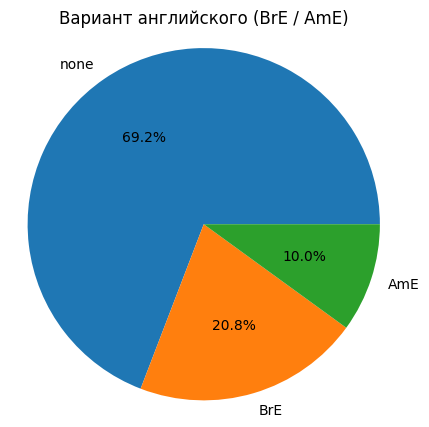

In [219]:
# # MIX  — найдено и то, и другое в одном тексте
# (!!! ХОРОШО, если этот показатель равен 0 - ибо за микс британского и американского могут снизить балл)

# Для наглядности покажем результат в виде
# круговой диаграммы распределения BrE / AmE / none / mix

labels = summary_df["label"]     # названия категорий
sizes = summary_df["count"]      # количество текстов в каждой категории

plt.figure(figsize=(5, 5))       # размер графика

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",           # показывать проценты в десятых
)

plt.title("Вариант английского (BrE / AmE)")
plt.axis("equal")                # чтобы был круг, а не эллипс

plt.show()

In [230]:
# Итоговая проверка структуры корпуса df_ok

# Все вычисленные метрики сохранены для воспроизводимости анализа:

print("Количество текстов:", len(df_ok))
print("Количество столбцов:", len(df_ok.columns))
print("\nСписок столбцов:")
print(df_ok.columns.tolist())

# И выведем их в более логичном порядке
preferred_order = [
    # ID и метаданные
    "doc_id", "source_url", "chart_type", "chart_type_rus", "band",

    # Текст
    "text_raw", "text_clean",

    # Токены // леммы
    "tokens", "tokens_no_stop", "lemmas_no_stop",

    # Метрики
    "wc_custom", "tokens_no_stop_count", "types_count", "ttr",

    # Анализ
    "overall_count", "overall_present", "pos_counter"
]

# Берём только те, которые реально есть (чтобы код не падал)
existing_preferred = []
for col in preferred_order:
    if col in df_ok.columns:
        existing_preferred.append(col)

# Добавляем “в хвост” всё остальное, что не вошло (чтобы ничего не потерять)
rest = []
for col in df_ok.columns:
    if col not in existing_preferred:
        rest.append(col)

df_ok = df_ok[existing_preferred + rest]

print("Первые строки корпуса df_ok:")
df_ok.head()

Количество текстов: 120
Количество столбцов: 17

Список столбцов:
['doc_id', 'source_url', 'chart_type', 'band', 'text_raw', 'text_clean', 'tokens', 'tokens_no_stop', 'lemmas_no_stop', 'wc_custom', 'tokens_no_stop_count', 'types_count', 'ttr', 'overall_count', 'overall_present', 'pos_counter', 'chart_type_rus']
Первые строки корпуса df_ok:


,doc_id,source_url,chart_type,chart_type_rus,band,text_raw,text_clean,tokens,tokens_no_stop,lemmas_no_stop,wc_custom,tokens_no_stop_count,types_count,ttr,overall_count,overall_present,pos_counter
0,0001,https://ieltsliz.com/ielts-diagram/,process_diagram,Описание процесса,NaN,The diagram illustrates how an Australian town...,the diagram illustrates how an australian town...,"[the, diagram, illustrates, how, an, australia...","[diagram, illustrates, australian, town, proce...","[diagram, illustrate, australian, town, proces...",179,87,56,0.643678,1,True,"{'NOUN': 50, 'VERB': 19, 'ADJ': 12, 'ADV': 4, ..."
1,0002,https://ieltsliz.com/ielts-pie-chart-task-1-mo...,pie_chart,Круговая диаграмма,9.0,The two pie charts illustrate the proportion o...,the two pie charts illustrate the proportion o...,"[the, two, pie, charts, illustrate, the, propo...","[two, pie, charts, illustrate, proportion, fiv...","[two, pie, chart, illustrate, proportion, five...",177,78,46,0.589744,1,True,"{'OTHER': 3, 'NOUN': 45, 'VERB': 13, 'ADJ': 11..."
2,0003,https://ieltsliz.com/dec-2016-ielts-writing-ta...,mixed,Смешанный тип,8.0,The bar chart and pie charts illustrate the pe...,the bar chart and pie charts illustrate the pe...,"[the, bar, chart, and, pie, charts, illustrate...","[bar, chart, pie, charts, illustrate, percenta...","[bar, chart, pie, chart, illustrate, percentag...",202,87,51,0.586207,1,True,"{'NOUN': 52, 'VERB': 10, 'OTHER': 4, 'ADJ': 16..."
3,0004,https://ieltsliz.com/ielts-diagram-model-answe...,mixed,Смешанный тип,9.0,The diagrams illustrate the steps and equipmen...,the diagrams illustrate the steps and equipmen...,"[the, diagrams, illustrate, the, steps, and, e...","[diagrams, illustrate, steps, equipment, invol...","[diagram, illustrate, step, equipment, involve...",194,103,77,0.747573,1,True,"{'NOUN': 46, 'VERB': 27, 'ADJ': 21, 'OTHER': 5..."
4,0005,https://ieltsliz.com/ielts-table-band-9-model-...,table,Таблица,9.0,The table gives information about how many ful...,the table gives information about how many ful...,"[the, table, gives, information, about, how, m...","[table, gives, information, many, full-time, s...","[table, give, information, many, full-time, st...",202,99,57,0.575758,1,True,"{'ADJ': 17, 'VERB': 18, 'NOUN': 52, 'ADV': 7, ..."


**Практическое применение корпуса**

Данный корпус IELTS Writing Task 1 используется не только для статистического анализа, но и как основа для создания интерактивного инструмента — Telegram-бота.

На данный момент бот выполняет две функции:

1) Исследовательская (визуализация корпусных данных)


2) Практическая (для сдающего IELTS)

Пользователь может:

- увидеть среднюю длину текстов данного типа

- узнать типичные глаголы

- посмотреть характерные сочетания verb + adverb

- понять, какой вариант написания преобладает (британский, американский)


Данный бот демонстрирует данные на основе реальных текстов

In [ ]:
# ЭКСПОРТ КОРПУСНЫХ ДАННЫХ ДЛЯ TELEGRAM-БОТА
#
# Данный блок преобразует агрегированные результаты анализа
# корпуса IELTS Writing Task 1 в формат JSON
#
# JSON используется как интерфейс между аналитическим
# ноутбуком (pandas) и Telegram-ботом
#
# Коллокации verb + adverb
pairs_df.to_json("pairs.json", orient="records", force_ascii=False)

# Длина текста + тип
df_ok[["chart_type", "chart_type_rus", "wc_custom"]].to_json(
    "lengths.json",
    orient="records",
    force_ascii=False
)

## Результаты работы


В ходе работы был сформирован корпус IELTS Writing Task 1 и проведён базовый лингвистический анализ в среде Python с использованием Pandas

Выполнены очистка и токенизация текстов, удаление стоп-слов, расчёт частотных характеристик и построение POS-профиля корпуса

Отдельно выявлены типичные для жанра конструкционные паттерны, в частности коллокации типа VERB+ADV (rose significantly, increased slightly и др.), отражающие “шаблонную” лексику описания динамики

Дополнительно оценена орфографическая вариативность BrE/AmE: в большинстве текстов отсутствуют диагностические маркеры (none), при этом британские формы встречаются чаще американских
В дальнейшем проект можно улучшить за счёт лемматизации, расширения набора паттернов (например, ADJ+NOUN), а также сохранения предрасчитанных результатов для использования в Telegram-боте 